# Практика 17. Проста лінійна регресія

**Варіант 7 — Івано-Франківськ**

Мета роботи: побудувати модель простої лінійної регресії для залежності витрат на опалення від середньомісячної температури, визначити коефіцієнти моделі, коефіцієнт детермінації R², проаналізувати залишки та виконати прогноз.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

In [2]:
np.random.seed(7)

city = "Івано-Франківськ"

monthly_temp = [
    -4, -3, 1, 7, 12, 15,
    17, 16, 12, 7, 2, -2
]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print(climate)

               місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Івано-Франківськ    Січ           -4               25                  3.3
1   Івано-Франківськ    Лют           -3               21                  3.6
2   Івано-Франківськ    Бер            1               16                  2.4
3   Івано-Франківськ    Кві            7               11                  0.0
4   Івано-Франківськ    Тра           12                8                  1.8
5   Івано-Франківськ    Чер           15                2                  0.1
6   Івано-Франківськ    Лип           17                2                  0.0
7   Івано-Франківськ    Сер           16                2                  0.0
8   Івано-Франківськ    Вер           12                7                  1.2
9   Івано-Франківськ    Жов            7               11                  0.1
10  Івано-Франківськ    Лис            2               18                  2.9
11  Івано-Франківськ    Гру           -2            

In [3]:
x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

print(f"Slope: {result.slope:.3f}")
print(f"Intercept: {result.intercept:.3f}")
print(f"r: {result.rvalue:.3f}")
print(f"p-value: {result.pvalue:.6f}")

print(
    f"Рівняння регресії: "
    f"витрати ≈ {result.intercept:.3f} "
    f"{result.slope:+.3f} × температура"
)

Slope: -0.187
Intercept: 2.938
r: -0.842
p-value: 0.000599
Рівняння регресії: витрати ≈ 2.938 -0.187 × температура


### Висновок до Завдання 1

Для Івано-Франківська отримано рівняння простої лінійної регресії:

**витрати ≈ 2.938 − 0.187 × температура.**

Коефіцієнт нахилу `b1 = -0.187` означає, що при збільшенні середньомісячної температури на 1°C очікувані витрати на опалення в середньому зменшуються приблизно на **0.187 тис. грн**, тобто приблизно на **187 грн**.

Від'ємний знак коефіцієнта є логічним: зі зростанням температури потреба в опаленні зменшується, тому зменшуються і витрати.

Коефіцієнт перетину `b0 = 2.938` формально означає прогнозовані витрати при температурі 0°C — приблизно 2.938 тис. грн.


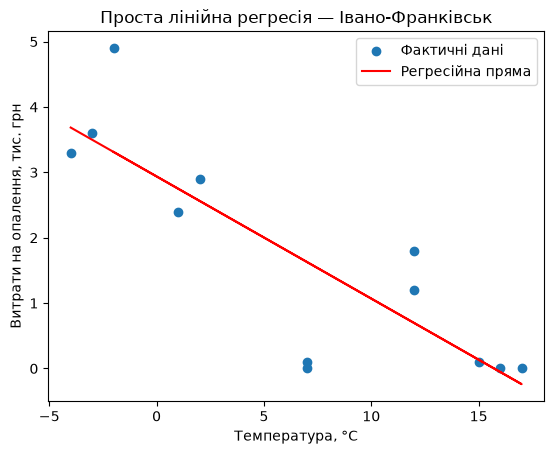

In [4]:
predicted = result.intercept + result.slope * x

plt.scatter(
    x,
    y,
    label="Фактичні дані"
)

plt.plot(
    x,
    predicted,
    color="red",
    label="Регресійна пряма"
)

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Проста лінійна регресія — Івано-Франківськ")
plt.legend()
plt.show()

In [5]:
r_squared_1 = result.rvalue ** 2

predicted = result.intercept + result.slope * x

ss_res = np.sum((y - predicted) ** 2)
ss_total = np.sum((y - y.mean()) ** 2)

r_squared_2 = 1 - ss_res / ss_total

print(f"SS залишків: {ss_res:.6f}")
print(f"SS загальна: {ss_total:.6f}")

print(f"R² через rvalue²: {r_squared_1:.6f}")
print(f"R² через формулу: {r_squared_2:.6f}")

SS залишків: 9.449871
SS загальна: 32.389167
R² через rvalue²: 0.708240
R² через формулу: 0.708240


In [ ]:
pearson_result = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

pearson_r_squared = pearson_result.statistic ** 2

print(f"r Пірсона: {pearson_result.statistic:.6f}")
print(f"r² Пірсона: {pearson_r_squared:.6f}")
print(f"R² регресії: {r_squared_1:.6f}")